In [4]:
from sys import path

path.append("..")

import os
from pathlib import Path

os.chdir(Path.cwd().parent)

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from src.graph_utils.reading import read_metadata
from src.settings import Settings


In [6]:
metadata = read_metadata()

In [7]:

def count_elements(row_array):
    if len(row_array) == 1 and row_array[0] == -1:
        return 0
    return len(row_array)

test_data = pd.read_parquet(Settings.processed_datasets_dir / 'table.parquet')
test_data['count'] = test_data['result'].apply(count_elements)

test_data['percentage'] = test_data.apply(lambda x: x['count'] / metadata[x['dataset_name']]['graph_count'], axis=1)

In [8]:
test_data = test_data.reset_index(drop=True)
test_data.head(30)

,features,dataset_name,result,count,percentage
0,[common_neigbours],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
1,[jaccard_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
2,[adamic_adar],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
3,[katz_index],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 11, 12, 21, 9, ...",18,0.529412
4,[neighborhood_distance],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
5,[neighborhood_measure],graph5,"[4, 13]",2,0.058824
6,[preferential_attachment],graph5,"[4, 13]",2,0.058824
7,[resource_allocation],graph5,"[2, 5, 3, 6, 8, 4, 10, 13, 20, 15, 26]",11,0.323529
8,[same_community],graph5,"[2, 5, 3, 6, 7, 11, 12, 15, 26, 9, 13, 16, 17,...",26,0.764706
9,[total_nieghbors],graph5,"[14, 26]",2,0.058824


In [9]:
test_data['result'].iloc[0]

array([ 2,  5,  3,  6,  8,  4, 10, 13, 20, 11, 12, 21,  9, 19, 16, 24, 15,
       26])

In [10]:

test_data['features'] = test_data['features'].astype('string').astype('category')
test_data.columns

Index(['features', 'dataset_name', 'result', 'count', 'percentage'], dtype='object')

In [11]:
test_data.sort_values('count').head(20)

,features,dataset_name,result,count,percentage
8469,['edge_betweenness' 'eigenvector_centrality' '...,eul9,[-1],0,0.0
8468,['edge_betweenness_normalized' 'katz_centralit...,eul9,[-1],0,0.0
8467,['betweenness_normalized' 'edge_betweenness_no...,eul9,[-1],0,0.0
5857,['resource_allocation'],selfcomp9,[-1],0,0.0
5800,['algebraic_distance:modk_graph3'],selfcomp12,[-1],0,0.0
5825,['neighborhood_measure' 'neighborhood_measure:...,selfcomp12,[-1],0,0.0
8456,['edge_betweenness_normalized' 'katz_centralit...,eul8,[-1],0,0.0
8455,['betweenness_normalized' 'edge_betweenness_no...,eul8,[-1],0,0.0
1639,['edge_betweenness_normalized' 'edge_betweenne...,highlyirregular14,[-1],0,0.0
1638,['edge_betweenness' 'edge_betweenness:k_graph2...,highlyirregular14,[-1],0,0.0


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def calculate_metrics(df):
    # mean
    mean_score = df.mean(axis=1)

    # power mean
    def power_mean(df, p, epsilon=1e-12):
        df_safe = df + epsilon
        
        if p == 0:
            return np.exp(np.log(df_safe).mean(axis=1))
        else:
            return (df_safe.pow(p).mean(axis=1)) ** (1 / p)

    p0_score = power_mean(df, p=0)    # geometric
    p_1_score = power_mean(df, p=-1)  # harmonic
    p_2_score = power_mean(df, p=-2)    # strong penalty for zeros


    # size
    sizes = pd.Series({
        dataset: metadata[dataset]['graph_count']
        for dataset in df.columns
    })
    weights_size = sizes / sizes.sum()

    weighted_mean_size = (df * weights_size).sum(axis=1)

    # difficulty
    dataset_difficulty =  1 - df.mean(axis=0)
    difficulty_weights = dataset_difficulty / dataset_difficulty.sum()

    weighted_mean_difficulty = (df * difficulty_weights).sum(axis=1)

    results = pd.DataFrame({
        "mean": mean_score,
        "p=0 (geom)": p0_score,
        "p=-1 (harm)": p_1_score,
        "p=-2": p_2_score,
        "weighted_size": weighted_mean_size,
        "weighted_difficulty": weighted_mean_difficulty
    })
    return results

In [13]:
def show_table(data2d, metrics, size=(20, 35)):
    fig, (ax1, ax2) = plt.subplots(
        1, 2,
        figsize=size,

        gridspec_kw={'width_ratios': [7, 1]}
    )

    sns.heatmap(
        data2d,
        cmap='plasma_r',
        vmin=0, vmax=1,
        annot=np.round(data2d * 100, 1),
        fmt=".0f",
        cbar=False,
        ax=ax1
    )

    sns.heatmap(
        metrics,
        cmap='viridis',
        vmin=0, vmax=1,
        annot=np.round(metrics * 100, 1),
        fmt=".0f",
        cbar=False,
        ax=ax2
    )
    ax2.set_yticks([])
    ax2.set_ylabel("")

    plt.tight_layout()

In [ ]:
from typing import List
def name_to_latex(name: str) -> List:
    name = name.replace('\n', '')
    
    if name[0] != '[':
        return [name.replace('_', r'\_')]
    for s in ["[", "]", "'"]:
        name = name.replace(s, "")

    name_list: List[str] = name.split(" ")

    for i, part in enumerate(name_list):
        name_list[i] = part.replace('_', ' ')


    ldp = {"ldp degree", "ldp max", "ldp mean", "ldp min", "ldp std"}
    if len(ldp.intersection(set(name_list))) == 5:
        name_list = ["LDP"]
    if len(set(map(lambda x: x+ ' normalized' if 'degree' not in x else x, ldp)).intersection(set(name_list))) == 5:
        name_list = ["LDP normalized"]
    return name_list

def generate_latex_table(df: pd.DataFrame, caption, label, bigger=True):
    
    latex_intro = rf'''
\begin{{center}}
\setlength{{\tabcolsep}}{{1.3pt}}
\renewcommand{{\arraystretch}}{{1.3}}
\tiny

\begin{{tabular}}{{ {"|l|" + "c|" * len(df.columns)} }} 
\hline
\\ & \multicolumn{{{len(df.columns)}}}{{|c|}}{{Descriptor}} \\
\hline
Dataset & { ' & '.join(map(lambda col: rf"\begin{{sideways}} {', '.join(name_to_latex(col))} \end{{sideways}}" ,df.columns)) } \\
\hline
'''

    latex_outro = rf'''
\hline
\end{{tabular}}
\captionof{{table}}{{ {caption} }}
\label{{tab:{label}}}
\end{{center}}
'''
    tex = latex_intro
    
    for row in df.iterrows():
        name = row[0]
        
        name = name_to_latex(name)
        new_line = ", ".join(name) + " & "
        
        values = np.round(row[1] , 2)
        best_score = np.argwhere(values == (np.amax(values) if bigger else np.amin(values))).flatten()
        
        def values_to_latex(x):
            i = x[0]
            x = x[1]
            return(
                (r"\cellcolor[HTML]{9CFC9C}" if i in best_score else "") + 
                ('0.' if x == 0 else f"{x:.2f}".lstrip('0').replace(".00", "."))
            )
        new_line = new_line + " & ".join(map(
            values_to_latex, enumerate(values.tolist()))) + '\\\\\n'
        
        tex = tex + new_line # + "\\hline\n"
    
    tex = tex + latex_outro
    return tex


    # print(np.round(row[1] * 100, 1).astype(int))


In [51]:
def full_show(data2d, caption, label, size=(20,35)):
    df = 1 - data2d
    metrics = calculate_metrics(df)

    show_table(data2d, metrics, size=size)
    plt.show()

    return (generate_latex_table(df.transpose(), caption, label))
    


### Single Descriptors

In [84]:

data2d = test_data[
    (~test_data['features'].str.contains('rounded3') 
    & ~(test_data['features'].str.contains(' '))
    & ~test_data['dataset_name'].str.contains('brec_400')
    
    & ~test_data['dataset_name'].str.contains('regular-2000')
    & ~(test_data['dataset_name'].str.contains(r'graph\d(?!c)') ) # for fair comparison only connected graphs

    & ~test_data['features'].str.contains('k_graph')

    # those are unstable
    & ~(
        test_data['features'].str.contains('algebraic_distance(?!_rounded)')
        | test_data['features'].str.contains('katz_index(?!_rounded)')
        | test_data['features'].str.contains('lss')
        | test_data['features'].str.contains('same_community')
        | test_data['features'].str.contains('spanning_edge')
        )
    )

]

data2d = data2d.pivot(index="features", columns="dataset_name", values="percentage")
data2d = data2d.sort_index()

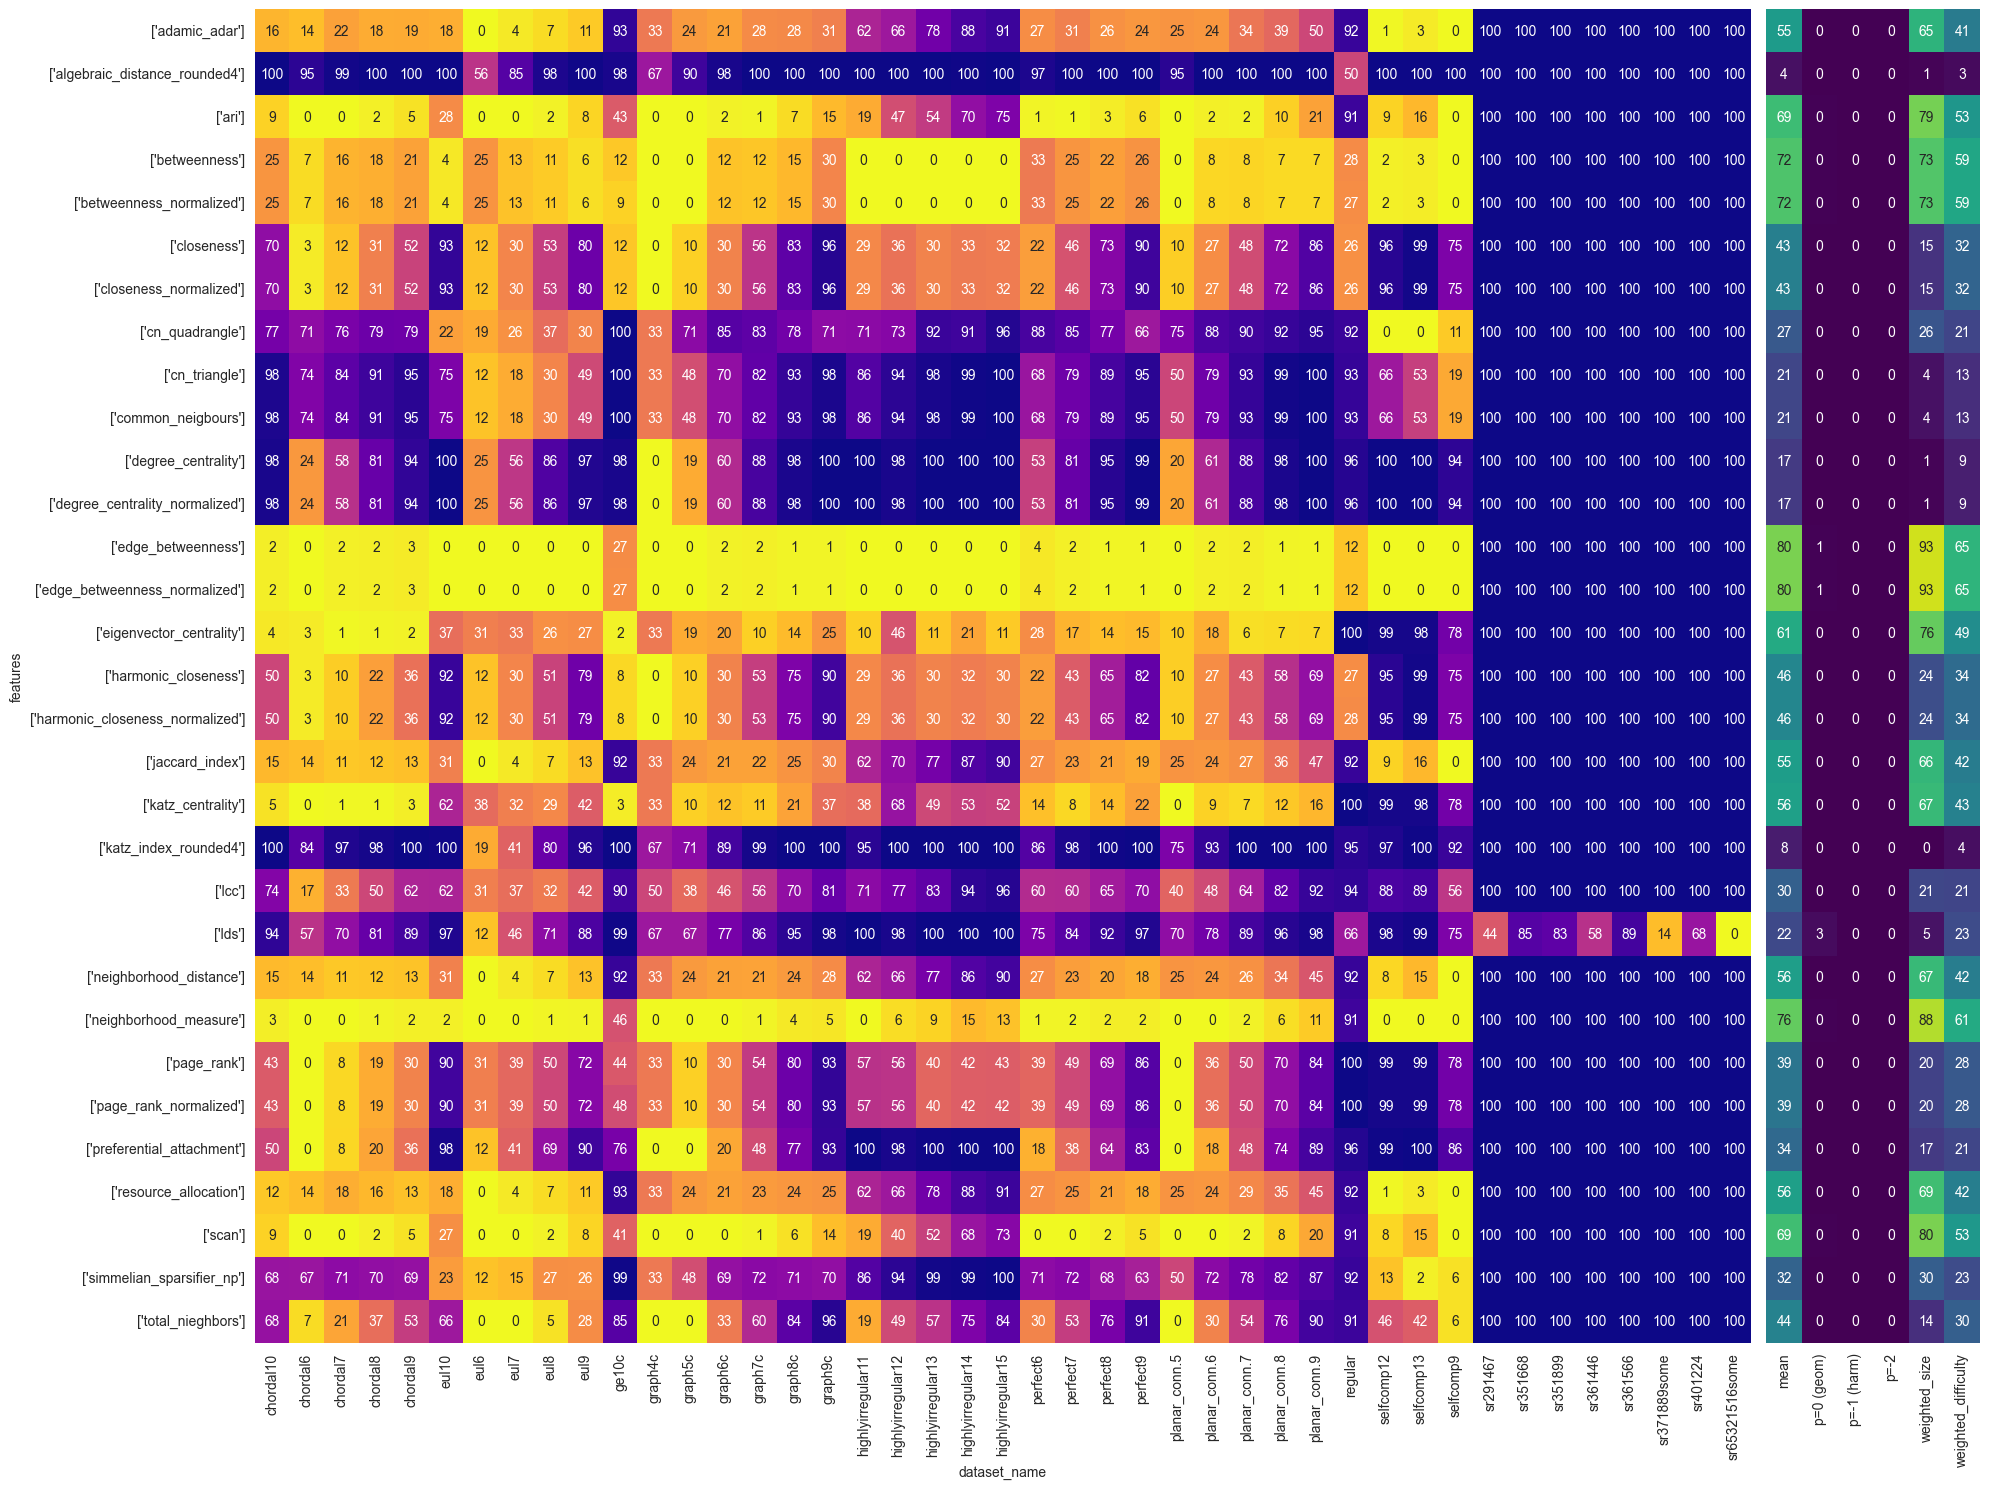

In [85]:
table_latex = full_show(
    data2d, 
    caption="Single Descriptor results, on green are marked best results per dataset",
    label="GD-single-descriptors",
    size=(20,15))

In [75]:
print(table_latex)


\begin{center}
\setlength{\tabcolsep}{1.3pt}
\renewcommand{\arraystretch}{1.3}
\tiny

\begin{tabular}{ |l|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c| } 
\hline
\\ & \multicolumn{31}{|c|}{Descriptor} \\
\hline
Dataset & \begin{sideways} adamic adar \end{sideways} & \begin{sideways} algebraic distance rounded4 \end{sideways} & \begin{sideways} ari \end{sideways} & \begin{sideways} betweenness \end{sideways} & \begin{sideways} betweenness normalized \end{sideways} & \begin{sideways} closeness \end{sideways} & \begin{sideways} closeness normalized \end{sideways} & \begin{sideways} cn quadrangle \end{sideways} & \begin{sideways} cn triangle \end{sideways} & \begin{sideways} common neigbours \end{sideways} & \begin{sideways} degree centrality \end{sideways} & \begin{sideways} degree centrality normalized \end{sideways} & \begin{sideways} edge betweenness \end{sideways} & \begin{sideways} edge betweenness normalized \end{sideways} & \begin{sideways} eigenvector centrality 

### K2 graphs

In [88]:

data2d = test_data[
    (~test_data['features'].str.contains('rounded3') 
    & ~(test_data['features'].str.contains(' '))
    & ~test_data['dataset_name'].str.contains('brec_400')
    
    & ~test_data['dataset_name'].str.contains('regular-2000')
    & ~(test_data['dataset_name'].str.contains(r'graph\d(?!c)') ) # for fair comparison only connected graphs

    & test_data['features'].str.contains('k_graph2')

    # those are unstable
    & ~(
        test_data['features'].str.contains('algebraic_distance(?!_rounded)')
        | test_data['features'].str.contains('katz_index(?!_rounded)')
        | test_data['features'].str.contains('lss')
        | test_data['features'].str.contains('same_community')
        | test_data['features'].str.contains('spanning_edge')
        )
    )

]

data2d = data2d.pivot(index="features", columns="dataset_name", values="percentage")
data2d = data2d.sort_index()

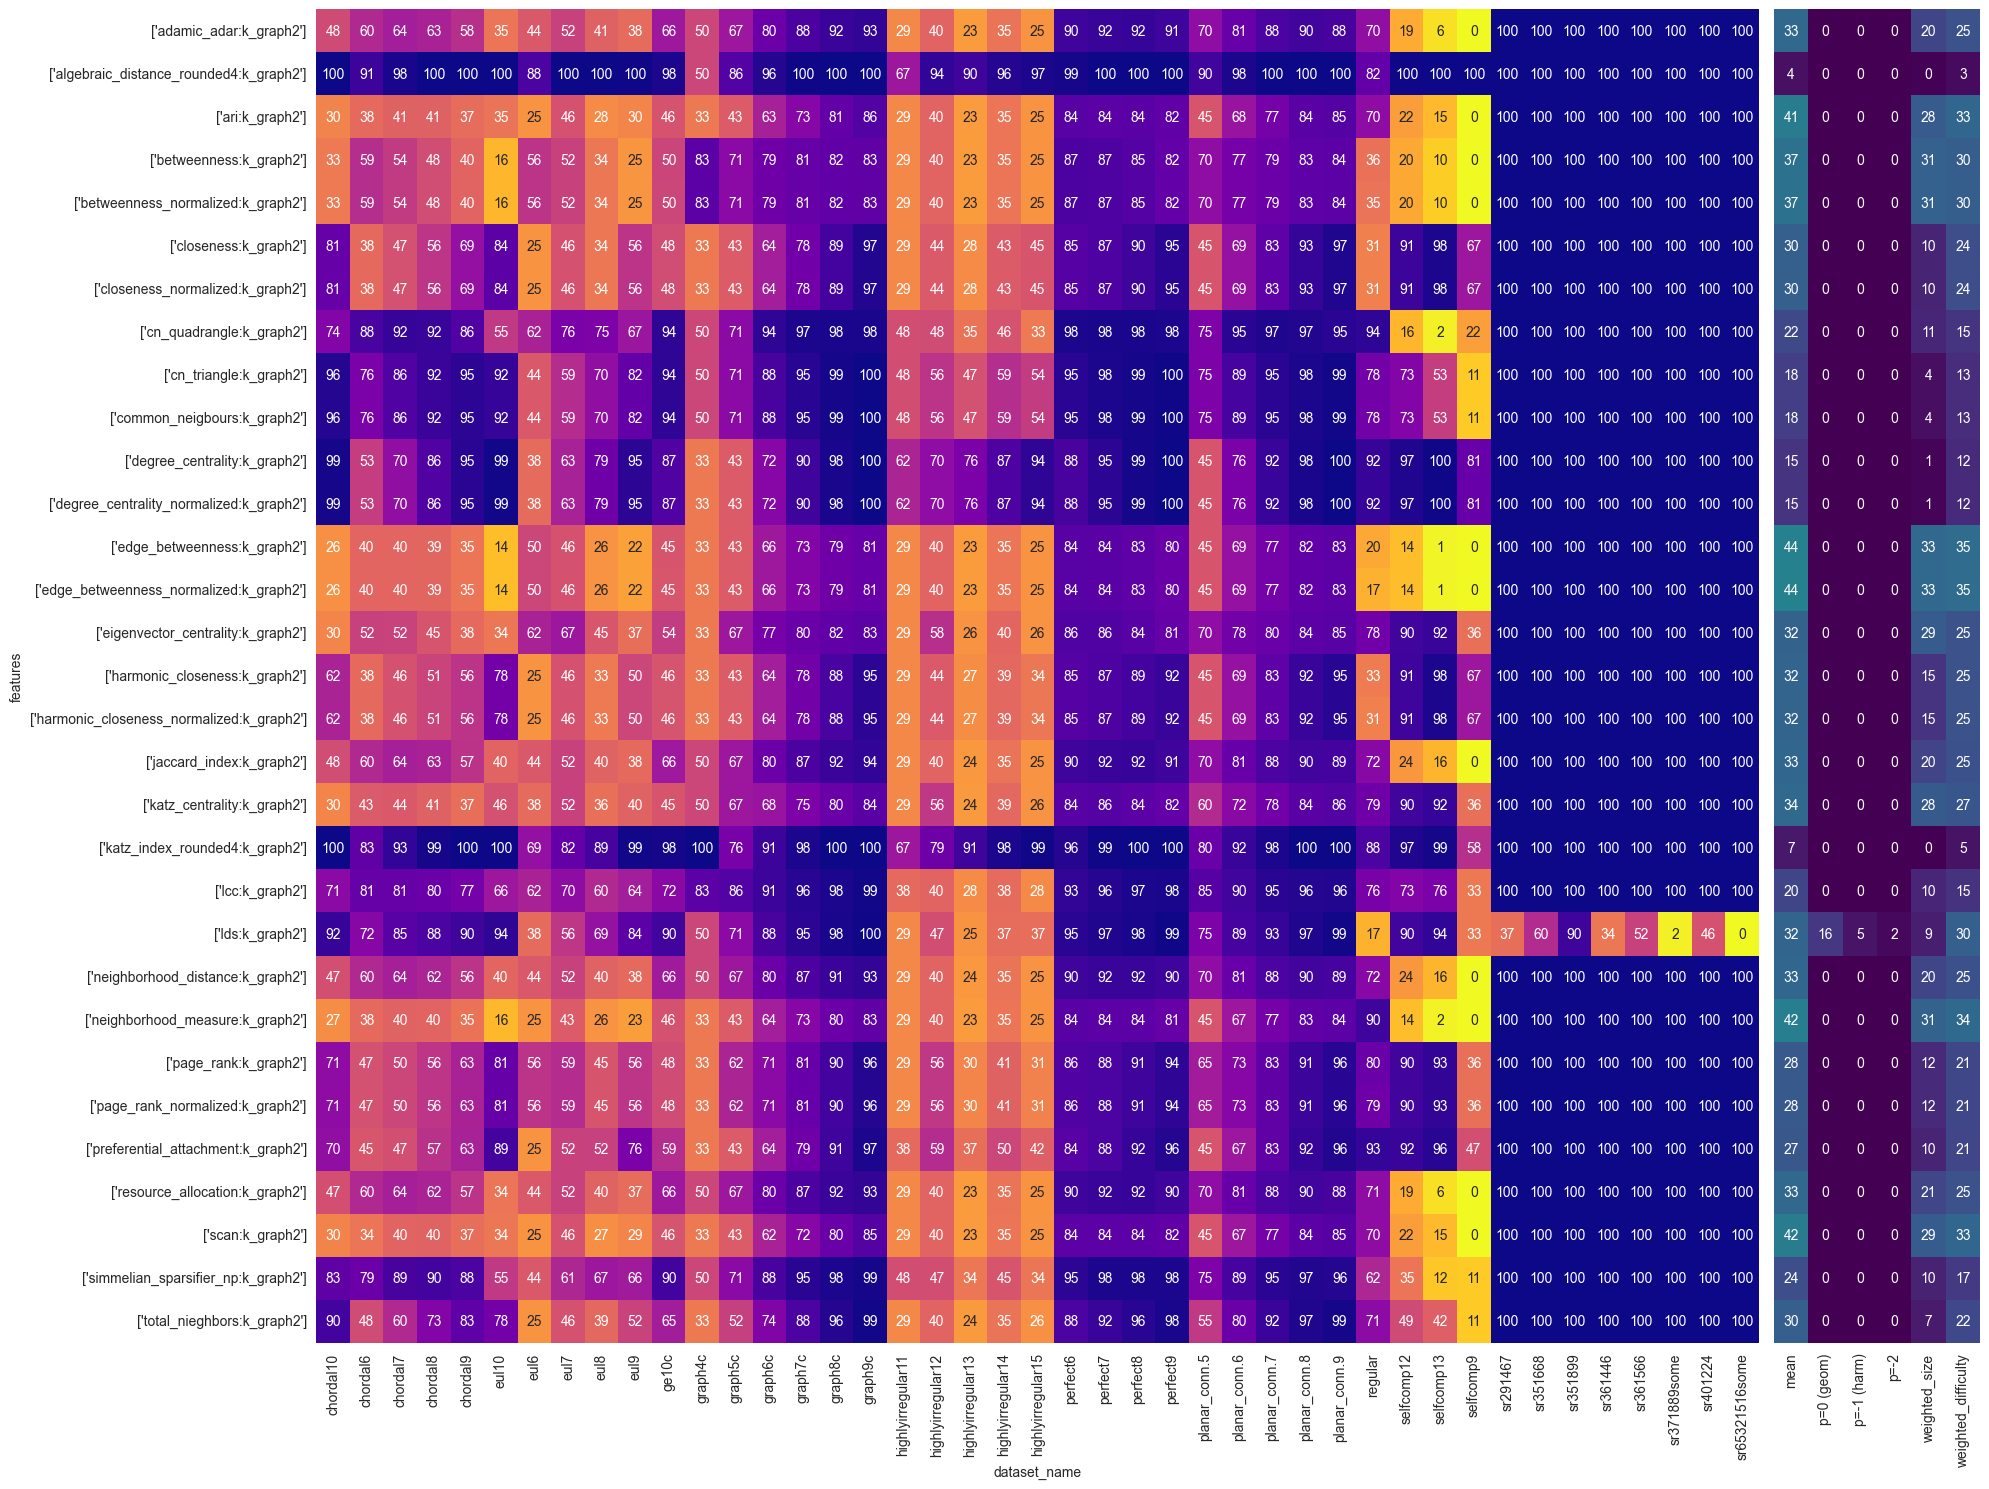

In [89]:
table_latex = full_show(
    data2d, 
    caption="Single Descriptor on 2-graphs",
    label="GD-single-descriptors-2k",
    size=(20,15))

In [90]:
print(table_latex)


\begin{center}
\setlength{\tabcolsep}{1.3pt}
\renewcommand{\arraystretch}{1.3}
\tiny

\begin{tabular}{ |l|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c|c| } 
\hline
\\ & \multicolumn{31}{|c|}{Descriptor} \\
\hline
Dataset & \begin{sideways} adamic adar:k graph2 \end{sideways} & \begin{sideways} algebraic distance rounded4:k graph2 \end{sideways} & \begin{sideways} ari:k graph2 \end{sideways} & \begin{sideways} betweenness:k graph2 \end{sideways} & \begin{sideways} betweenness normalized:k graph2 \end{sideways} & \begin{sideways} closeness:k graph2 \end{sideways} & \begin{sideways} closeness normalized:k graph2 \end{sideways} & \begin{sideways} cn quadrangle:k graph2 \end{sideways} & \begin{sideways} cn triangle:k graph2 \end{sideways} & \begin{sideways} common neigbours:k graph2 \end{sideways} & \begin{sideways} degree centrality:k graph2 \end{sideways} & \begin{sideways} degree centrality normalized:k graph2 \end{sideways} & \begin{sideways} edge betweenness:k graph2 \e

In [49]:
data2d = test_data[
    test_data['features'].str.contains(' ')
    & test_data['features'].str.contains('lds')
]


data2d = data2d.pivot(index="features", columns="dataset_name", values="percentage")
data2d = data2d.sort_index()